# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [4]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [1]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    # Load data, handle whitespace delimiters, and prevent dropping the first row as a header
    X_train = pd.read_csv(root_dir + "/train/X_train.txt", sep='\s+', header=None)
    y_train = pd.read_csv(root_dir + "/train/y_train.txt", sep='\s+', header=None)
    X_test = pd.read_csv(root_dir + "/test/X_test.txt", sep='\s+', header=None)
    y_test = pd.read_csv(root_dir + "/test/y_test.txt", sep='\s+', header=None)
    
    # TODO 5: Convert labels to zero-based indices
    y_train = y_train - 1
    y_test = y_test - 1
    return X_train, y_train, X_test, y_test
    # raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
print(num_features)
num_classes = len(class_names) 


561


## 5. Quick Inspection


In [4]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
sample_counts = y_train[0].value_counts().sort_index().values

# Create the summary table
summary_table = pd.DataFrame({
    "Class Index": range(len(class_names)),
    "Class Name": class_names,
    "Training Samples": sample_counts
})



print(summary_table)

   Class Index          Class Name  Training Samples
0            0             WALKING              1226
1            1    WALKING_UPSTAIRS              1073
2            2  WALKING_DOWNSTAIRS               986
3            3             SITTING              1286
4            4            STANDING              1374
5            5              LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    lr = 1e-3
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=lr),
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy'],
    )
    #raise NotImplementedError("Complete the baseline DNN.")
    return model
baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 561)]             0         
                                                                 
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    x = X_train,
    y = y_train,
    validation_split = 0.2,
    epochs = 40,
    batch_size = 64,
    callbacks = callbacks

    
)

Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1398 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1150 - accuracy: 0.9572 - val_loss: 0.2550 - val_accuracy: 0.9164
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0916 - accuracy: 0.9636 - val_loss: 0.1449 - val_accuracy: 0.9422
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0873 - accuracy: 0.9657 - val_loss: 0.2036 - val_accuracy: 0.9259
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0743 - accuracy: 0.9696 - val_loss: 0.1790 - val_accuracy: 0.9388
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0662 - accuracy: 0.9747 - val_loss: 0.1292 - val_accuracy: 0.9483
Epoch 8/40
92/92 [==

In [7]:
print(history.history)

{'loss': [0.488006055355072, 0.16378508508205414, 0.11498704552650452, 0.0915997102856636, 0.08725710213184357, 0.07432150095701218, 0.06616739928722382, 0.055896367877721786, 0.06486082822084427, 0.04883338138461113, 0.04738880693912506, 0.07723803073167801], 'accuracy': [0.8075157403945923, 0.9374256134033203, 0.9571501612663269, 0.9636116027832031, 0.9656521081924438, 0.9695630073547363, 0.9746641516685486, 0.9795953035354614, 0.9741540551185608, 0.9809556007385254, 0.9819758534431458, 0.9722836017608643], 'val_loss': [0.2016085833311081, 0.13984909653663635, 0.25504493713378906, 0.14494745433330536, 0.2036212682723999, 0.17895543575286865, 0.12916211783885956, 0.14522488415241241, 0.13392981886863708, 0.17053771018981934, 0.1931142359972, 0.15195827186107635], 'val_accuracy': [0.9245411157608032, 0.9374575018882751, 0.9163833856582642, 0.942216157913208, 0.9259007573127747, 0.9388171434402466, 0.9483344554901123, 0.9483344554901123, 0.947654664516449, 0.9442555904388428, 0.94017672

### Training Curves


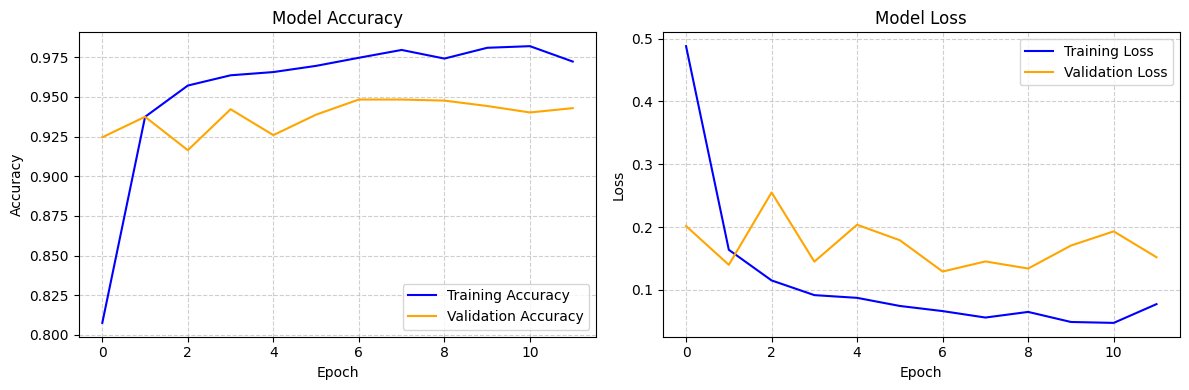

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
# Set up a wider figure to hold two plots side-by-side
plt.figure(figsize=(12, 4))

# --- Plot 1: Training and Validation Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Training and Validation Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Ensure plots don't overlap and display them
plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 526us/step
Test Accuracy: 0.9332

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       496
           1       0.86      0.97      0.92       471
           2       0.99      0.83      0.90       420
           3       0.94      0.88      0.91       491
           4       0.88      0.95      0.91       532
           5       1.00      0.98      0.99       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



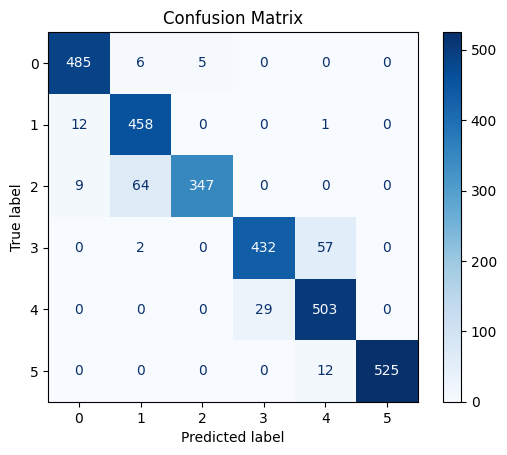

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
predicted_prob = baseline_model.predict(X_test)

y_pred = np.argmax(predicted_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plotting with a blue colormap for better readability
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]
    
    # raise NotImplementedError("Complete the representative dataset generator.")

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x / input_scale) + input_zero_point
            x = np.round(x).astype(input_details["dtype"])
        # <-- Enter your code here <--#
        

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        # <-- Enter your code here <--#

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    return converter.convert()
    # <-- Enter your code here <--#

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    return converter.convert()
    # <-- Enter your code here <--#

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]

    return converter.convert()
    # <-- Enter your code here <--#

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    converter.representative_dataset = representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    
    # Set inference_input_type and inference_output_type to tf.int8
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    # <-- Enter your code here <--#
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [25]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
# 1. Convert the models (The Translation Phase)
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_fp16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

# 2. Save to disk and record sizes (The Publishing Phase)
print("\n--- Model File Sizes ---")
size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
size_dynamic = save_binary_model(tflite_dynamic, "model_dynamic.tflite")
size_fp16 = save_binary_model(tflite_fp16, "model_fp16.tflite")
size_int8 = save_binary_model(tflite_int8, "model_int8.tflite")

print(f"Baseline (FP32):    {size_fp32:.2f} KB")
print(f"Dynamic Range:      {size_dynamic:.2f} KB")
print(f"Float16:            {size_fp16:.2f} KB")
print(f"Full INT8:          {size_int8:.2f} KB")

# 3. Evaluate each model on the test set (The Testing Phase)
print("\n--- Model Accuracies ---")
acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
acc_dynamic, _ = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
acc_fp16, _ = evaluate_tflite_model(tflite_fp16, X_test, y_test)
acc_int8, _ = evaluate_tflite_model(tflite_int8, X_test, y_test)

print(f"Baseline (FP32):    {acc_fp32:.4f}")
print(f"Dynamic Range:      {acc_dynamic:.4f}")
print(f"Float16:            {acc_fp16:.4f}")
print(f"Full INT8:          {acc_int8:.4f}")

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3tjm5gaz/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3tjm5gaz/assets
2026-04-19 19:53:41.565086: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:53:41.565099: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:53:41.565215: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3tjm5gaz
2026-04-19 19:53:41.565850: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:53:41.565855: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3tjm5gaz
2026-04-19 19:53:41.567135: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 19:53:41.589875: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3hpodnfs/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3hpodnfs/assets
2026-04-19 19:53:41.875379: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:53:41.875389: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:53:41.875494: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3hpodnfs
2026-04-19 19:53:41.876008: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:53:41.876012: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp3hpodnfs
2026-04-19 19:53:41.877331: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 19:53:41.899759: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp948mckvd/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp948mckvd/assets
2026-04-19 19:53:42.196623: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:53:42.196634: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:53:42.196737: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp948mckvd
2026-04-19 19:53:42.197309: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:53:42.197314: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp948mckvd
2026-04-19 19:53:42.198780: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 19:53:42.222171: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmphkvih_f4/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmphkvih_f4/assets
/Users/y/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-19 19:53:42.510056: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:53:42.510068: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:53:42.510197: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmphkvih_f4
2026-04-19 19:53:42.510885: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:53:42.510893: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xy


--- Model File Sizes ---
Baseline (FP32):    726.63 KB
Dynamic Range:      186.02 KB
Float16:            365.58 KB
Full INT8:          185.25 KB

--- Model Accuracies ---
Baseline (FP32):    0.9332
Dynamic Range:      0.9335
Float16:            0.9332
Full INT8:          0.9338


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
data = {
    "Model Family": ["Baseline DNN", "Baseline DNN", "Baseline DNN", "Baseline DNN"],
    "Format": ["FP32", "Dynamic Range", "Float16", "INT8"],
    "Test Accuracy": [acc_fp32, acc_dynamic, acc_fp16, acc_int8],
    "Model Size (KB)": [size_fp32, size_dynamic, size_fp16, size_int8]
}

# Create and display the DataFrame
df_comparison = pd.DataFrame(data)
print("--- Optimization Results ---")
display(df_comparison)

--- Optimization Results ---


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,FP32,0.933152,726.628906
1,Baseline DNN,Dynamic Range,0.933492,186.023438
2,Baseline DNN,Float16,0.933152,365.582031
3,Baseline DNN,INT8,0.933831,185.250000


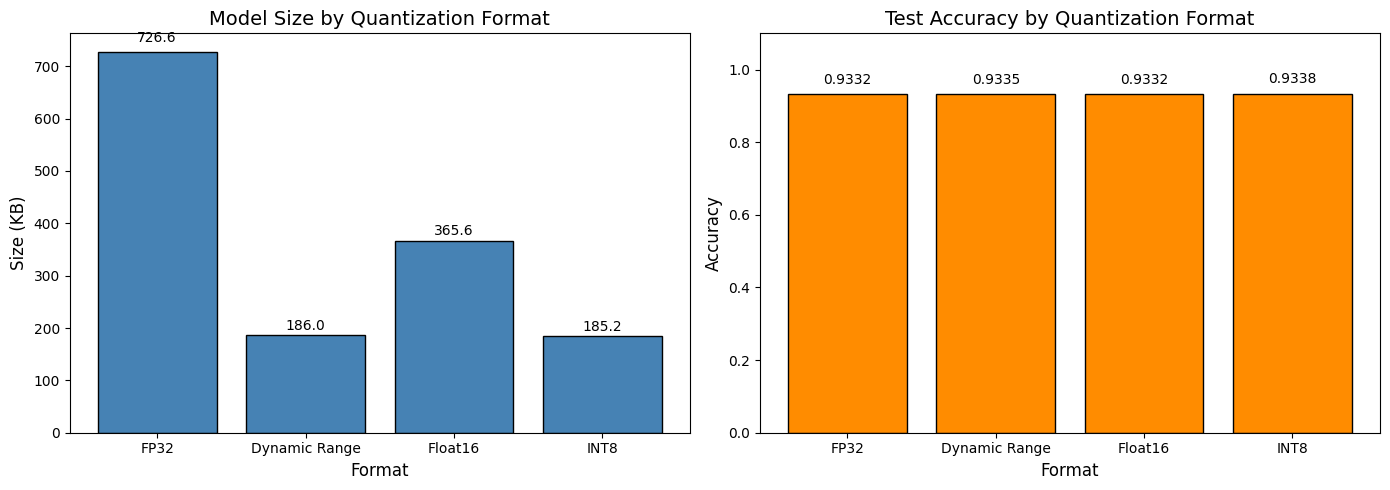

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
plt.figure(figsize=(14, 5))

# Plot 1: Model Size
plt.subplot(1, 2, 1)
bars_size = plt.bar(df_comparison['Format'], df_comparison['Model Size (KB)'], color='steelblue', edgecolor='black')
plt.title('Model Size by Quantization Format', fontsize=14)
plt.ylabel('Size (KB)', fontsize=12)
plt.xlabel('Format', fontsize=12)

# Add exact numbers on top of the bars for readability
for bar in bars_size:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.1f}', ha='center', va='bottom')

# Plot 2: Test Accuracy
plt.subplot(1, 2, 2)
bars_acc = plt.bar(df_comparison['Format'], df_comparison['Test Accuracy'], color='darkorange', edgecolor='black')
plt.title('Test Accuracy by Quantization Format', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Format', fontsize=12)

# Set the y-axis limits to zoom in on the differences (assuming accuracy is around 0.5 - 1.0)
# We set the upper limit slightly above 1.0 to leave room for the text labels
plt.ylim(0, 1.1)

# Add exact numbers on top of the bars
for bar in bars_acc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


0.9338310145911096
Classification Report (INT8 PTQ Model):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       496
           1       0.86      0.97      0.92       471
           2       0.99      0.83      0.90       420
           3       0.94      0.88      0.91       491
           4       0.88      0.95      0.91       532
           5       1.00      0.98      0.99       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



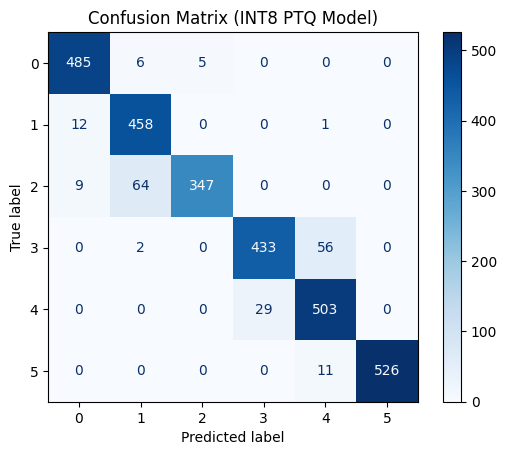

In [15]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

acc_int8_baseline, y_pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)
print(acc_int8_baseline)
# 2. Print the classification report
print("Classification Report (INT8 PTQ Model):")
print(classification_report(y_test, y_pred_int8))

# 3. Plot the confusion matrix
cm_int8 = confusion_matrix(y_test, y_pred_int8)
disp_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8)

# Plotting with a green colormap to visually distinguish it from your baseline plot
disp_int8.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (INT8 PTQ Model)")
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [16]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

qat_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 561)]             0         
                                                                 
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                     

### Fine-Tune the QAT Model


In [18]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
# Fine-tune the quantization-aware model
history_qat = qat_model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    epochs=8,
    batch_size=64,
)




Epoch 1/8
92/92 [==============================] - 1s 3ms/step - loss: 0.0687 - accuracy: 0.9738 - val_loss: 0.1402 - val_accuracy: 0.9463
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0707 - accuracy: 0.9726 - val_loss: 0.1292 - val_accuracy: 0.9463
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0721 - accuracy: 0.9748 - val_loss: 0.1353 - val_accuracy: 0.9504
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0579 - accuracy: 0.9789 - val_loss: 0.1373 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0459 - accuracy: 0.9837 - val_loss: 0.1224 - val_accuracy: 0.9538
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0394 - accuracy: 0.9849 - val_loss: 0.1885 - val_accuracy: 0.9422
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0432 - accuracy: 0.9825 - val_loss: 0.1401 - val_accuracy: 0.9524
Epoch 8/8
93/93 [==========

### Evaluate the QAT Keras Model


In [19]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.
qat_predicted_prob = qat_model.predict(X_test)

y_pred_qat = np.argmax(qat_predicted_prob, axis=1)

# <-- Enter your code here <--#
qat_loss, qat_accuracy = qat_model.evaluate(X_test, y_test)
print(f"QAT Keras test accuracy: {qat_accuracy:.4f}")

# 2. Print the classification report
print("Classification Report (QAT Keras Model):")
print(classification_report(y_test, y_pred_qat))

93/93 [==============================] - 0s 687us/step - loss: 0.2464 - accuracy: 0.9294
QAT Keras test accuracy: 0.9294
Classification Report (QAT Keras Model):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       496
           1       0.94      0.93      0.93       471
           2       0.94      0.92      0.93       420
           3       0.96      0.84      0.90       491
           4       0.83      0.97      0.89       532
           5       1.00      0.95      0.97       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [22]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_int8 = convert_to_tflite_int8(qat_model)
qat_size_int8 = save_binary_model(qat_int8, "qat_int8.tflite")

print(f"QAT INT8:          {qat_size_int8:.2f} KB")

# 3. Evaluate each model on the test set (The Testing Phase)
print("\n--- Model Accuracies ---")
qat_acc_int8, _ = evaluate_tflite_model(qat_int8, X_test, y_test)
print(f"QAT INT8:          {qat_acc_int8:.4f}")

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpk9936w9y/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpk9936w9y/assets
/Users/y/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-19 19:50:57.566968: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:50:57.566980: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:50:57.567076: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpk9936w9y
2026-04-19 19:50:57.568303: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:50:57.568309: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xy

Full INT8:          185.61 KB

--- Model Accuracies ---
Full INT8:          0.9294


## 12. PTQ Int8 vs QAT Int8


In [26]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
data = {
    "Model Family": ["Baseline DNN", "Baseline DNN"],
    "Format": ["PTQ int8", "QAT int8"],
    "Test Accuracy": [acc_int8, qat_acc_int8],
    "Model Size (KB)": [size_int8, qat_size_int8]
}

# Create and display the DataFrame
df_comparison = pd.DataFrame(data)
print("--- Optimization Results ---")
display(df_comparison)

--- Optimization Results ---


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,PTQ int8,0.933831,185.250000
1,Baseline DNN,QAT int8,0.929420,185.609375


Classification Report (INT8 PTQ Model):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       496
           1       0.94      0.93      0.93       471
           2       0.94      0.92      0.93       420
           3       0.96      0.84      0.90       491
           4       0.83      0.97      0.89       532
           5       1.00      0.95      0.97       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



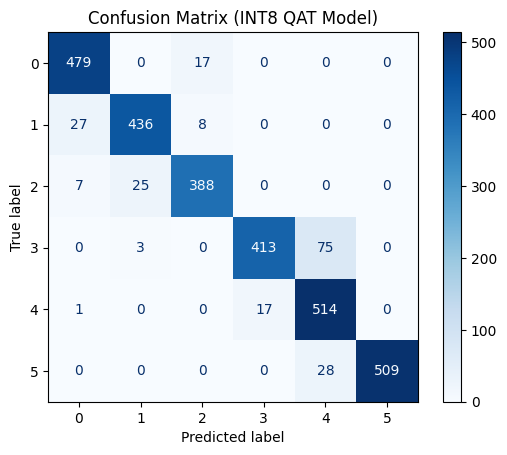

In [27]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
_, qat_y_pred_int8 = evaluate_tflite_model(qat_int8, X_test, y_test)
# 2. Print the classification report
print("Classification Report (INT8 PTQ Model):")
print(classification_report(y_test, qat_y_pred_int8))

# 3. Plot the confusion matrix
qat_cm_int8 = confusion_matrix(y_test, qat_y_pred_int8)
disp_int8 = ConfusionMatrixDisplay(confusion_matrix=qat_cm_int8)

# Plotting with a green colormap to visually distinguish it from your baseline plot
disp_int8.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (INT8 QAT Model)")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


1. PTQ gives the smallest model size
2. PTQ gives the best accuracy
3. no significant improvements
4. This dataset is a good fit because its features can be successfully mapped to highly accurate predictions (over 93%) using a relatively simple, straightforward Dense Neural Network (DNN). It does not require complex, memory-heavy architectures like massive CNNs or Transformers to find the patterns, allowing the final quantized model to remain extremely small (~185 KB) and fast enough for an edge device.
5. I would choose the PTQ int8 version. Based on the optimization results, it achieved the best test accuracy (93.38%) while simultaneously maintaining the smallest memory footprint (185.25 KB)

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
